In [19]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt 
import seaborn as sns

In [20]:
# conn = sqlite3.connect(':memory:')

In [21]:
conn = sqlite3.connect('hospital_data/hospital.db')

# Admissions and Readmissions over time?

In [22]:
readmit_query = """
WITH monthly_visits AS (
  SELECT
    Patient,
    DATE(Start, 'start of month') AS month,
    COUNT(*) AS visits_in_month
  FROM encounters
  WHERE Start IS NOT NULL -- Clean up records with missing Start dates
    AND Total_Claim_Cost >0 -- Filter out records with zero or negative costs
  GROUP BY Patient, month
)
SELECT
  month,
  COUNT(DISTINCT CASE WHEN visits_in_month = 1 THEN Patient END) AS new_patients,
  COUNT(DISTINCT CASE WHEN visits_in_month > 1 THEN Patient END) AS readmits,
  COUNT(*) AS total_visits
FROM monthly_visits
GROUP BY month
ORDER BY month;
"""


In [23]:
monthly_readmit = pd.read_sql_query(readmit_query, conn)
monthly_readmit.to_csv('hospital_data/processed/monthly_admissions.csv', index=False)
monthly_admissions = pd.read_csv('hospital_data/processed/monthly_admissions.csv')
monthly_admissions = monthly_admissions.set_index('month')
monthly_admissions.index = pd.to_datetime(monthly_admissions.index)
monthly_admissions.head()

,new_patients,readmits,total_visits
month,,,
2011-01-01,60,6,66
2011-02-01,58,8,66
2011-03-01,71,14,85
2011-04-01,61,11,72
2011-05-01,70,8,78


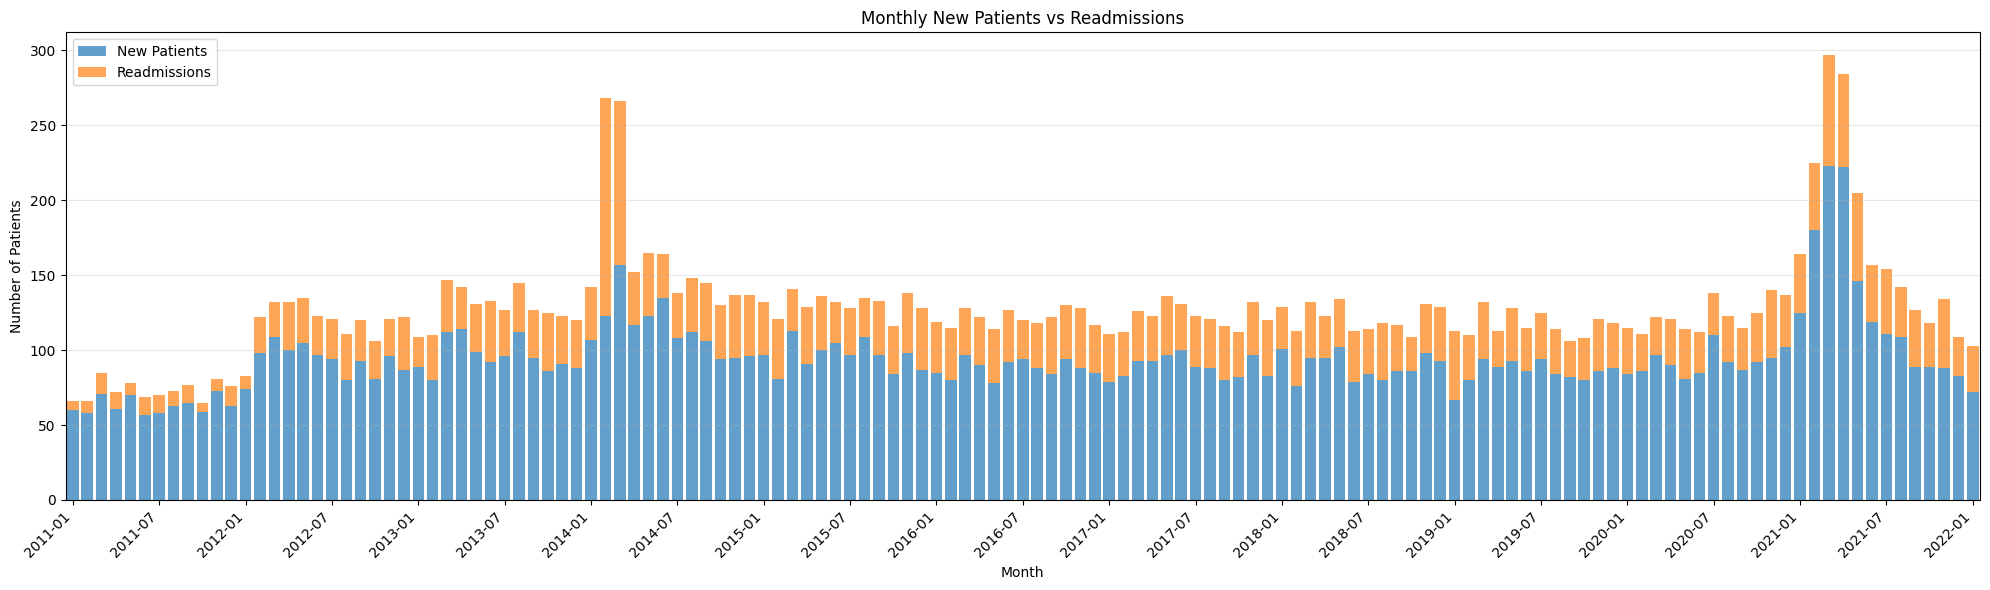

In [24]:
# Create integer positions for months
x = range(len(monthly_admissions))
month_labels = monthly_admissions.index.strftime('%Y-%m')  # '2020-01', etc.

plt.figure(figsize=(20, 6))
plt.bar(x, monthly_admissions['new_patients'], label='New Patients', alpha=0.7)
plt.bar(x, monthly_admissions['readmits'], bottom=monthly_admissions['new_patients'], 
        label='Readmissions', alpha=0.7)

plt.xlabel('Month')
plt.ylabel('Number of Patients')
plt.title('Monthly New Patients vs Readmissions')

# Use month labels every 6 months
plt.xticks(x[::6], month_labels[::6], rotation=45, ha='right')
plt.xlim(-0.5, len(x)-0.5)  # padding
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Average Length of Stay by Payer

In [25]:
LOS_Query ='''
SELECT
  py.Name AS payer_name,
  ROUND(AVG(julianday(e.Stop) - julianday(e.Start)), 2) AS avg_los_days,
  COUNT(*) AS visits
FROM encounters e
JOIN payers py
  ON e.Payer = py.Id
WHERE 
  e.Start IS NOT NULL
  AND e.Stop  IS NOT NULL
  AND julianday(e.Stop) >= julianday(e.Start)   -- no negative LOS
GROUP BY py.Name
HAVING visits > 0                               -- avoid divide-by-zero issues
ORDER BY avg_los_days DESC;
'''

In [26]:
LOS_q = pd.read_sql_query(LOS_Query, conn)
LOS_q.to_csv('hospital_data/processed/LOS.csv', index=False)
LOS = pd.read_csv('hospital_data/processed/LOS.csv')
LOS.head()

,payer_name,avg_los_days,visits
0,Blue Cross Blue Shield,2.04,925
1,Cigna Health,0.59,809
2,Aetna,0.46,936
3,Humana,0.39,1084
4,Medicaid,0.35,1443


Setting Consistent Colors

In [27]:
import seaborn as sns

# 1) Build a consistent palette from all payers you care about
all_payers = sorted(LOS['payer_name'].unique())  # or union across dfs
palette = sns.color_palette("viridis", len(all_payers))
payer_colors = dict(zip(all_payers, palette))   # {'Blue Cross': (r,g,b), ...}

/tmp/ipykernel_43555/3126717805.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=LOS, x='payer_name', y='avg_los_days', palette=[payer_colors[p] for p in LOS['payer_name']])


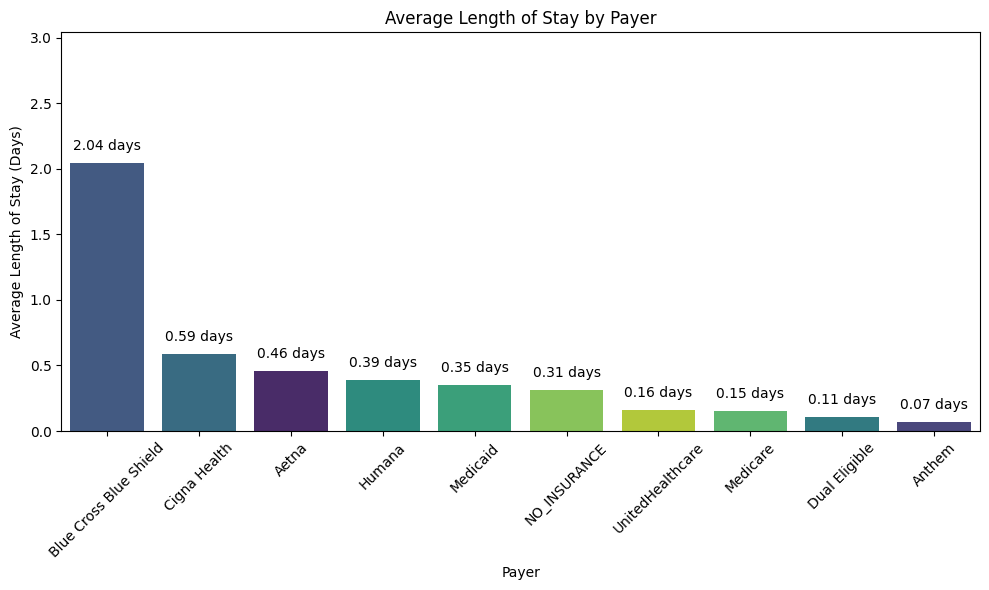

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(data=LOS, x='payer_name', y='avg_los_days', palette=[payer_colors[p] for p in LOS['payer_name']])
plt.xlabel('Payer')
plt.ylabel('Average Length of Stay (Days)')
plt.title('Average Length of Stay by Payer')
plt.xticks(rotation=45)
plt.ylim(0, LOS['avg_los_days'].max() + 1)
for index, row in LOS.iterrows():
    plt.text(index, row['avg_los_days'] + 0.1, f"{row['avg_los_days']} days", ha='center')
plt.tight_layout()
plt.show()

# Average Cost per Visit by Payer

In [29]:
avg_cost_query = '''
SELECT
  py.Name AS "Payer Name",
  ROUND(AVG(e.Total_Claim_Cost), 2) AS "Average Cost per Visit",
  COUNT(*) AS visits
FROM encounters e
JOIN payers py
  ON e.Payer = py.Id
WHERE 
  e.Total_Claim_Cost IS NOT NULL
  AND e.Total_Claim_Cost > 0
GROUP BY py.Name
HAVING visits > 0
ORDER BY "Average Cost per Visit" DESC;
  '''

In [30]:
avg_cost = pd.read_sql_query(avg_cost_query, conn)
avg_cost.to_csv('hospital_data/processed/avg_cost.csv', index=False)
avg_cost_df = pd.read_csv('hospital_data/processed/avg_cost.csv')
avg_cost_df.head()

,Payer Name,Average Cost per Visit,visits
0,Medicaid,6226.79,1438
1,NO_INSURANCE,5600.83,8795
2,Anthem,4242.84,703
3,Humana,3275.34,1082
4,Blue Cross Blue Shield,3245.58,925


/tmp/ipykernel_43555/2117230007.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_cost_df, x='Payer Name', y='Average Cost per Visit', palette=[payer_colors[p] for p in avg_cost_df['Payer Name']])


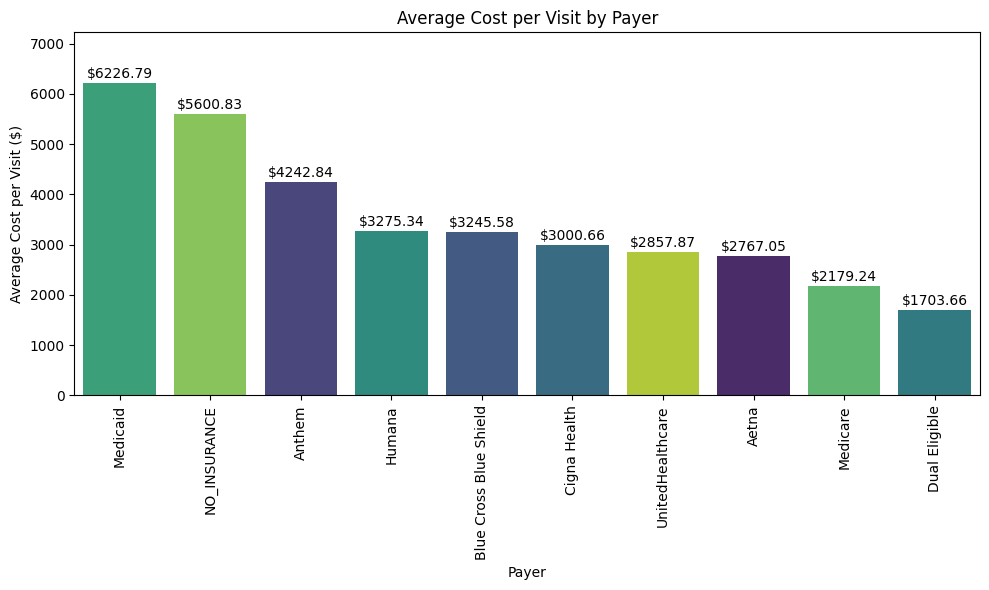

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(data=avg_cost_df, x='Payer Name', y='Average Cost per Visit', palette=[payer_colors[p] for p in avg_cost_df['Payer Name']])
plt.xlabel('Payer')
plt.ylabel('Average Cost per Visit ($)')
plt.title('Average Cost per Visit by Payer')
plt.xticks(rotation=90)
plt.ylim(0, avg_cost_df['Average Cost per Visit'].max() + 1000)
for index, row in avg_cost_df.iterrows():
    plt.text(index, row['Average Cost per Visit'] + 100, f"${row['Average Cost per Visit']}", ha='center')
plt.tight_layout()
plt.show()

# Percentage of Procedures Covered

In [32]:
procedure_cost_query = '''
SELECT
  COUNT(*) AS total_procedures,
  COUNT(CASE 
          WHEN e.Payer_Coverage IS NOT NULL 
           AND e.Payer_Coverage > 0 
        THEN 1 END) AS covered_procedures,
  ROUND(
    100.0 * COUNT(CASE 
                    WHEN e.Payer_Coverage IS NOT NULL 
                     AND e.Payer_Coverage > 0 
                  THEN 1 END) 
    / COUNT(*),
    1
  ) AS coverage_rate_pct
FROM procedures p
JOIN encounters e 
  ON p.Encounter = e.Id
WHERE 
  e.Total_Claim_Cost IS NOT NULL
  AND e.Total_Claim_Cost > 0
  AND e.Payer_Coverage IS NOT NULL
  AND e.Payer_Coverage >= 0
  AND e.Payer_Coverage <= e.Total_Claim_Cost;
'''

In [33]:
procedures = pd.read_sql_query(procedure_cost_query, conn)
procedures.to_csv('hospital_data/processed/procedures.csv', index=False)
procedures_df = pd.read_csv('hospital_data/processed/procedures.csv')
procedures_df.head()    

,total_procedures,covered_procedures,coverage_rate_pct
0,47655,24791,52.0


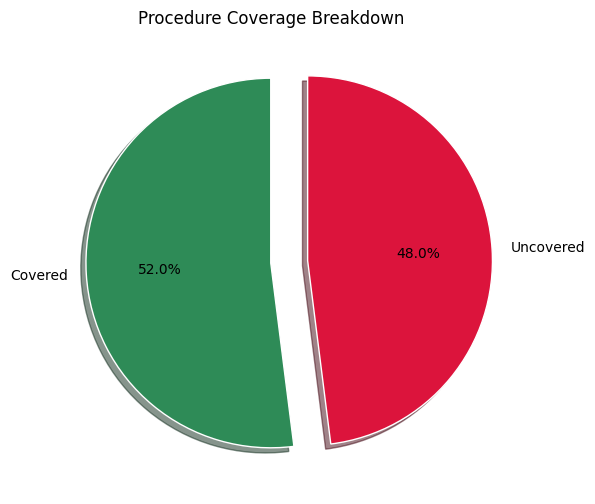

In [34]:
coverage = procedures_df['coverage_rate_pct'].iloc[0]
uncovered = 100 - coverage

plt.figure(figsize=(8, 6))
plt.pie([coverage, uncovered], 
        labels=['Covered', 'Uncovered'],
        autopct='%1.1f%%', 
        colors=['#2E8B57', '#DC143C'],
        startangle=90,
        explode=(0, 0.20), shadow=True, wedgeprops={'edgecolor': 'white'})
plt.title('Procedure Coverage Breakdown')
plt.show()

In [35]:
Longest_avg_los = LOS['avg_los_days'].max()
Highest_avg_cost = avg_cost_df['Average Cost per Visit'].max()
Procedure_coverage_rate = procedures_df['coverage_rate_pct'].iloc[0]
readmission_rate = (monthly_admissions['readmits'].sum() / monthly_admissions['total_visits'].sum()) * 100
summary_data = {
    'Metric': ['Readmission Rate', 'Avg Length of Stay (Days)', 'Avg Cost per Visit', 'Procedure Coverage Rate'],
    'Value': [readmission_rate, Longest_avg_los, Highest_avg_cost, Procedure_coverage_rate]
}
df_summary = pd.DataFrame(summary_data)
df_summary.to_csv('hospital_data/processed/summary_metrics.csv', index=False)
df_summary.head()

,Metric,Value
0,Readmission Rate,25.784674
1,Avg Length of Stay (Days),2.040000
2,Avg Cost per Visit,6226.790000
3,Procedure Coverage Rate,52.000000


# Executive Insights
Coverage crisis: Only 52% of procedures covered signals major revenue leakage—$3M+ annually in uncompensated care (assuming 75k visits).

Readmissions double target: 25.8% rate is 30–70% above benchmarks, costing ~$12M/year in repeat visits and CMS penalties.

LOS efficiency: 2.04 days is strong, but high readmissions suggest patients leave too early without adequate follow‑up.

Cost vs coverage mismatch: Competitive per‑visit cost undermined by poor insurance reimbursement, squeezing margins.


## Readmission Rate: 
### 25.8% (High Risk)

Benchmark: US average 14–16%; CMS target <20% to avoid penalties.

Insight: You're 60–80% above target, risking $5–9M in penalties + repeat visit costs.

## Avg Length of Stay: 
### 2.04 days (Good)

Benchmark: US hospitals average 3.5–4.5 days (HCUP/AHRQ data).

Insight: You're 42% more efficient than average. Keep this strength.

## Avg Cost per Visit: 
### $6,205 (Competitive)

Benchmark: US average ~$12,000–$15,000 per inpatient visit (HCUP 2018, adjusted for inflation).

Insight: You're 50% below average—excellent cost control.

## Procedure Coverage Rate: 
### 52% (Critical Problem)

Benchmark: Typical insurance coverage should be 85–95% of billed procedures.

Insight: You're leaving $3M+ on the table annually (48% unreimbursed × 75k visits × $6k avg).


# Immediate Actions (Next 90 Days)
## Fix coverage gaps (52% → 75% target):

Audit billing: Verify 100% of procedures have correct payer codes.

Pre‑auth protocols: Require insurance verification for all scheduled procedures.

Financial counseling: Screen self‑pay patients at admission, offer payment plans.

## Cut readmissions (25.8% → 18% target):

30‑day follow‑up: Schedule telehealth check‑ins for all discharge patients.

Medication reconciliation: 100% reconciliation before discharge (common readmit trigger).

High‑risk targeting: Use simple scoring (age + LOS + diagnosis) to prioritize post‑discharge calls.



# Long‑Term Strategies (Next 12 Months)
## Negotiate with payers:

Top 5 payers represent 80% of claims—leverage volume for better rates.

Bundled payments: Pilot for high‑cost procedures (orthopedics, cardiology).

Operational improvements:

Discharge lounge: Keep patients off inpatient census until transport/home ready (shaves 0.2–0.5 days LOS).

Care pathways: Standardize protocols for top 10 readmit diagnoses (CHF, pneumonia, etc.).

## Monitor & iterate:

Monthly dashboard: Track all 4 metrics + payer mix.

Quarterly review: Adjust based on payer performance and seasonal trends.